In [6]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from google.colab import files


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modelos classificadores
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

In [7]:
uploaded = files.upload()


Saving heart.csv to heart (1).csv


In [8]:
heart = list(uploaded.keys())[0]
print('Arquivo enviado:', heart)

df = pd.read_csv(heart)

df.head()

Arquivo enviado: heart (1).csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [9]:
print('Formato da base:', df.shape)

df.info()

Formato da base: (1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [10]:
# Estatísticas descritivas
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [11]:
print('Valores ausentes por coluna:')
print(df.isnull().sum())

Valores ausentes por coluna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [28]:
possiveis_targets = ['target', 'Target', 'HeartDisease', 'heart_disease', 'output', 'condition', 'Disease']

target_col = None
for col in possiveis_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    target_col = df.columns[-1]
    print('Target não identificado', target_col)
else:
    print('Target identificado:', target_col)

X = df.drop(columns=[target_col])
y = df[target_col]

print('Features:', X.columns.tolist())
print('Target:', target_col)
print('Distribuição da target:')
print(y.value_counts())

Target identificado: target
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target: target
Distribuição da target:
target
1    526
0    499
Name: count, dtype: int64


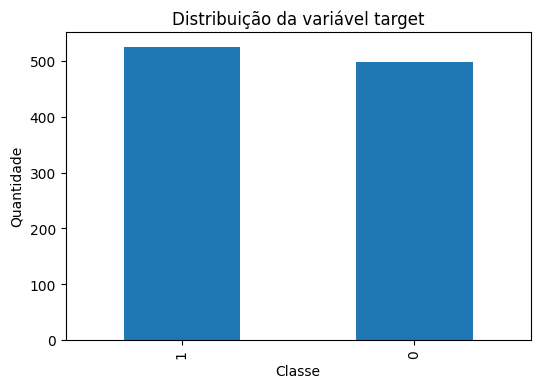

In [13]:
plt.figure(figsize=(6,4))
y.value_counts().plot(kind='bar')
plt.title('Distribuição da variável target')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.show()

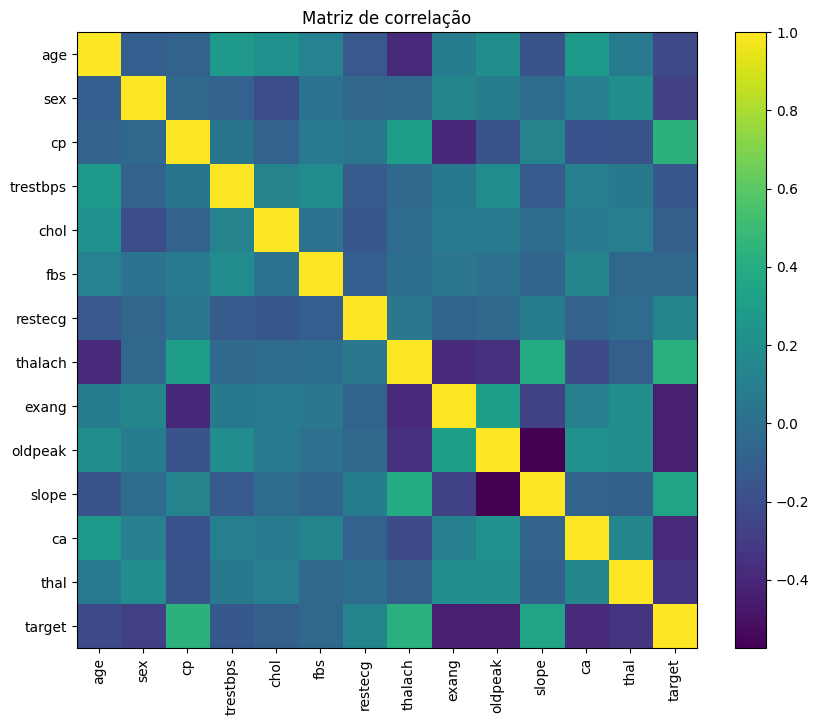

In [14]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,8))
plt.imshow(numeric_df.corr(), aspect='auto')
plt.colorbar()
plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=90)
plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)
plt.title('Matriz de correlação')
plt.show()

In [15]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('Colunas numéricas:', numeric_features)
print('Colunas categóricas:', categorical_features)

try:
    onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot_encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


Colunas numéricas: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Colunas categóricas: []


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)

Treino: (820, 13)
Teste: (205, 13)


In [17]:
knn_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

nb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', probability=True, random_state=42))
])

dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=5))
])

modelos = {
    'KNN': knn_model,
    'Naive Bayes': nb_model,
    'SVM': svm_model,
    'Árvore de Decisão': dt_model
}

In [18]:
resultados = []
modelos_treinados = {}

for nome, modelo in modelos.items():
    print('Treinando modelo:', nome)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    resultados.append({
        'Modelo': nome,
        'Acurácia': acc,
        'Precisão': prec,
        'Recall': rec,
        'F1-score': f1
    })

    modelos_treinados[nome] = modelo

    print(classification_report(y_test, y_pred, zero_division=0))

resultados_df = pd.DataFrame(resultados)
resultados_df

Treinando modelo: KNN
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       100
           1       0.87      0.86      0.87       105

    accuracy                           0.86       205
   macro avg       0.86      0.86      0.86       205
weighted avg       0.86      0.86      0.86       205

Treinando modelo: Naive Bayes
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       100
           1       0.81      0.88      0.84       105

    accuracy                           0.83       205
   macro avg       0.83      0.83      0.83       205
weighted avg       0.83      0.83      0.83       205

Treinando modelo: SVM
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       100
           1       0.92      0.94      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205


,Modelo,Acurácia,Precisão,Recall,F1-score
0,KNN,0.863415,0.863618,0.863415,0.863434
1,Naive Bayes,0.829268,0.831469,0.829268,0.828754
2,SVM,0.926829,0.927144,0.926829,0.926787
3,Árvore de Decisão,0.873171,0.873620,0.873171,0.873062


Matriz de Confusão - KNN
[[87 13]
 [15 90]]


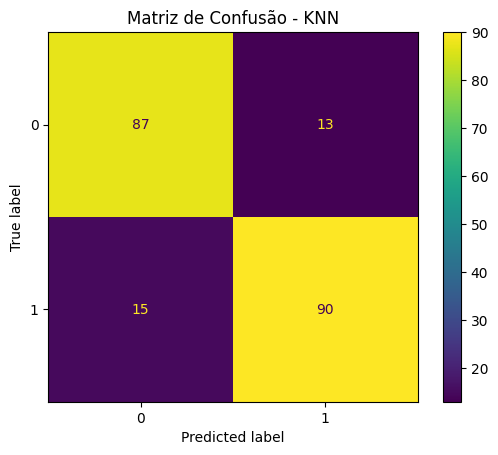

Matriz de Confusão - Naive Bayes
[[78 22]
 [13 92]]


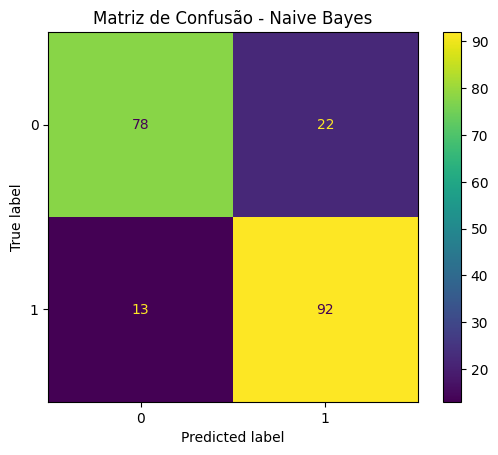

Matriz de Confusão - SVM
[[91  9]
 [ 6 99]]


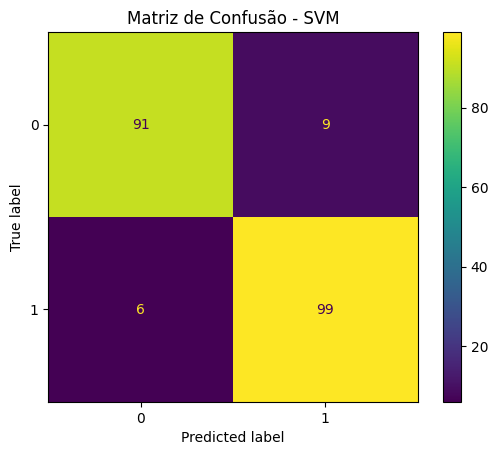

Matriz de Confusão - Árvore de Decisão
[[85 15]
 [11 94]]


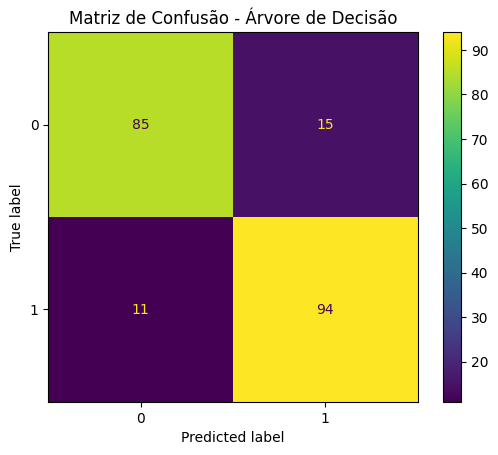

In [19]:
for nome, modelo in modelos_treinados.items():
    y_pred = modelo.predict(X_test)

    print(f'Matriz de Confusão - {nome}')
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Matriz de Confusão - {nome}')
    plt.show()


In [20]:
comite = VotingClassifier(
    estimators=[
        ('knn', knn_model),
        ('nb', nb_model),
        ('svm', svm_model),
        ('dt', dt_model)
    ],
    voting='hard'
)

comite.fit(X_train, y_train)


y_pred_comite = comite.predict(X_test)

# Avaliação do comitê
acc = accuracy_score(y_test, y_pred_comite)
prec = precision_score(y_test, y_pred_comite, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred_comite, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred_comite, average='weighted', zero_division=0)

resultado_comite = pd.DataFrame([{
    'Modelo': 'Comitê - Votação Majoritária',
    'Acurácia': acc,
    'Precisão': prec,
    'Recall': rec,
    'F1-score': f1
}])

resultado_comite

,Modelo,Acurácia,Precisão,Recall,F1-score
0,Comitê - Votação Majoritária,0.926829,0.928946,0.926829,0.926805


Matriz de Confusão - Comitê de Classificadores
[[96  4]
 [11 94]]


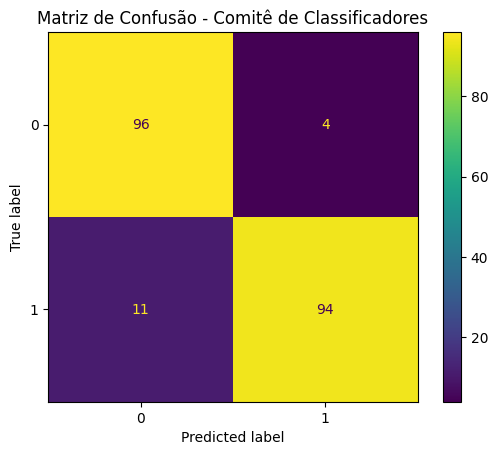

In [21]:
print('Matriz de Confusão - Comitê de Classificadores')
cm_comite = confusion_matrix(y_test, y_pred_comite)
print(cm_comite)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_comite)
disp.plot()
plt.title('Matriz de Confusão - Comitê de Classificadores')
plt.show()


In [22]:
comparacao = pd.concat([resultados_df, resultado_comite], ignore_index=True)
comparacao

,Modelo,Acurácia,Precisão,Recall,F1-score
0,KNN,0.863415,0.863618,0.863415,0.863434
1,Naive Bayes,0.829268,0.831469,0.829268,0.828754
2,SVM,0.926829,0.927144,0.926829,0.926787
3,Árvore de Decisão,0.873171,0.873620,0.873171,0.873062
4,Comitê - Votação Majoritária,0.926829,0.928946,0.926829,0.926805


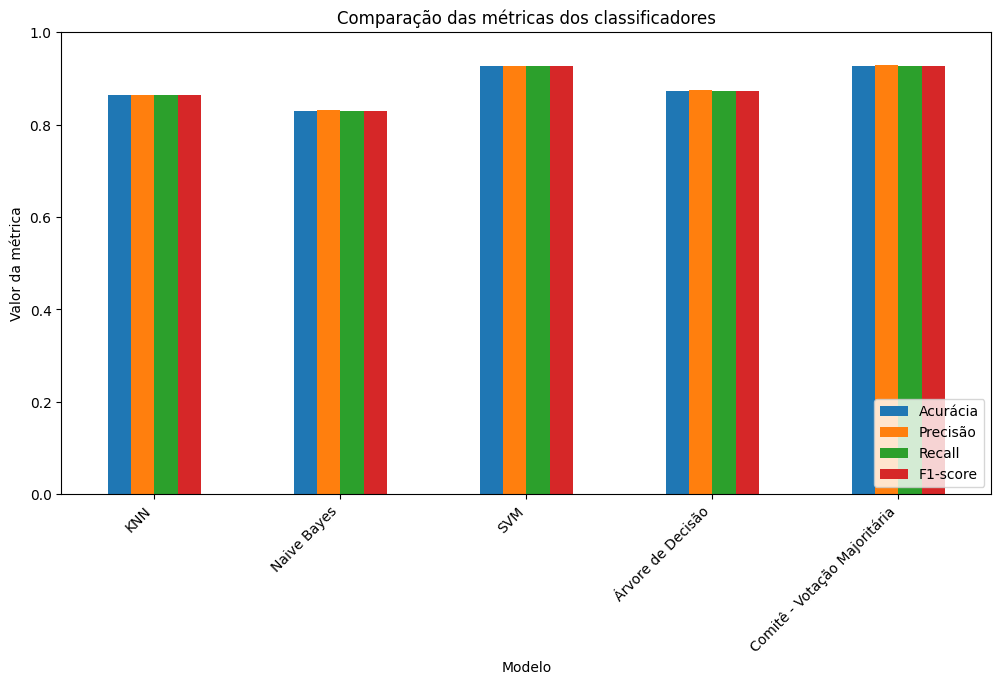

In [23]:
# Gráfico comparando as métricas
comparacao_plot = comparacao.set_index('Modelo')
comparacao_plot[['Acurácia', 'Precisão', 'Recall', 'F1-score']].plot(kind='bar', figsize=(12,6))
plt.title('Comparação das métricas dos classificadores')
plt.ylabel('Valor da métrica')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.show()

In [29]:
melhor_modelo = comparacao.sort_values(by='F1-score', ascending=False).iloc[0]

print('Melhor modelo pelo F1-score:')
print(melhor_modelo)

print('Conclusão:')
print('O projeto utilizou modelos individuais de classificação e um comitê baseado em votação majoritária.')
print('A comparação das métricas permite verificar se o comitê apresentou desempenho superior aos modelos individuais.')

Melhor modelo pelo F1-score:
Modelo      Comitê - Votação Majoritária
Acurácia                        0.926829
Precisão                        0.928946
Recall                          0.926829
F1-score                        0.926805
Name: 4, dtype: object
Conclusão:
O projeto utilizou modelos individuais de classificação e um comitê baseado em votação majoritária.
A comparação das métricas permite verificar se o comitê apresentou desempenho superior aos modelos individuais.
